# 02 - Three-Node Entanglement Swapping

## Objetivo
Demonstrar entrelaçamento fim a fim em uma cadeia linear `a - r - b`, onde
`r` gera entrelaçamento elementar com os dois vizinhos e realiza o swap,
comparando a estimativa de fidelidade do `IntentPlanner` com a fidelidade
realmente observada na simulação.

## Conceitos
- Topologia:

```text
a ---- r ---- b
```

  `r` é o único nó repetidor; `a` e `b` são os extremos do intent.
- `planning.feasibility.estimate_swap_only_fidelity` estima a fidelidade
  fim a fim como `produto(fidelidades por salto) x degradação(swap)` -
  usando a mesma fórmula que `EntanglementSwappingA_Circuit` realmente usa
  (`f1 * f2 * degradation`), nunca uma física inventada
  (`docs/sequence_code_analysis.md`, seção 4.3).
- A fidelidade *observada* vem exclusivamente de eventos `DELIVERY` reais
  (`docs/assurance_design.md`), nunca da estimativa do planner.


## Configuração


In [1]:
from ibqn.demos.topologies import three_node_spec
from ibqn.network.sequence_adapter import SequenceAdapter
from ibqn.network.capabilities import NetworkCapabilities
from ibqn.execution.sequence_executor import SequenceExecutor
from ibqn.intent.repository import IntentRepository
from ibqn.intent.models import (
    EntanglementIntent, IntentEndpoints, IntentRequirements, IntentValidation, SuccessCondition,
)
from ibqn.planning.planner import IntentPlanner

SEED = 0
REQUESTED_PAIRS = 10
MIN_FIDELITY = 0.65  # below the single-swap ceiling -> no purification needed (see notebook 03)
RAW_FIDELITY = 0.85
SWAPPING_DEGRADATION = 0.95

spec = three_node_spec(
    end_memories=REQUESTED_PAIRS, repeater_memories=REQUESTED_PAIRS * 2,
    raw_fidelity=RAW_FIDELITY, swapping_degradation=SWAPPING_DEGRADATION,
)

intent = EntanglementIntent(
    id="intent-three-node-demo",
    endpoints=IntentEndpoints(source="a", destination="b"),
    requirements=IntentRequirements(
        min_fidelity=MIN_FIDELITY, min_throughput=1, max_latency=1.0,
        requested_pairs=REQUESTED_PAIRS, start_time=0.02, duration=0.1,
    ),
    validation=IntentValidation(
        metrics=["delivered_pairs", "average_fidelity"],
        success_conditions=[
            SuccessCondition(metric="delivered_pairs", operator=">=", expected=REQUESTED_PAIRS),
            SuccessCondition(metric="average_fidelity", operator=">=", expected=MIN_FIDELITY),
        ],
    ),
)
print("a ---- r ---- b  (r = repeater/swap node)")
intent


a ---- r ---- b  (r = repeater/swap node)


EntanglementIntent(id='intent-three-node-demo', service='entanglement_distribution', endpoints=IntentEndpoints(source='a', destination='b'), requirements=IntentRequirements(min_fidelity=0.65, min_throughput=1.0, max_latency=1.0, requested_pairs=10, start_time=0.02, duration=0.1), policy=IntentPolicy(priority='normal', allow_rerouting=True, allow_purification=True, allow_multiple_paths=False), validation=IntentValidation(metrics=['delivered_pairs', 'average_fidelity'], success_conditions=[SuccessCondition(metric='delivered_pairs', operator='>=', expected=10.0), SuccessCondition(metric='average_fidelity', operator='>=', expected=0.65)]))

## Execução

O `IntentPlanner` decide a rota e estima a fidelidade *antes* de qualquer simulação rodar.


In [2]:
capabilities = NetworkCapabilities(spec)
planner = IntentPlanner(capabilities)
plan = planner.plan(intent)

print(f"route: {' -> '.join(plan.route)}")
print(f"estimated end-to-end fidelity (planner, pre-simulation): {plan.estimated_metrics.fidelity:.4f}")
print(f"requires_purification: {plan.requires_purification}")


2026-07-11 14:24:58,258 INFO     ibqn.ibqn.planning.planner intent_id=intent-three-node-demo - planned route a->r->b, estimated_fidelity=0.6864, purification=False


route: a -> r -> b
estimated end-to-end fidelity (planner, pre-simulation): 0.6864
requires_purification: False


In [3]:
adapter = SequenceAdapter(spec, seed=SEED)
repository = IntentRepository()
executor = SequenceExecutor(adapter, repository)

executor.deploy(intent, plan)
executor.run()

repository.get(intent.id).lifecycle.status


2026-07-11 14:24:58,279 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - topology built: 3 routers, 2 quantum links, seed=0


2026-07-11 14:24:58,282 INFO     ibqn.ibqn.intent.repository intent_id=intent-three-node-demo - intent registered


2026-07-11 14:24:58,283 INFO     ibqn.ibqn.intent.repository intent_id=intent-three-node-demo - intent transitioned to VALIDATED (schema validated)


2026-07-11 14:24:58,284 INFO     ibqn.ibqn.intent.repository intent_id=intent-three-node-demo - intent transitioned to PLANNING (invoking IntentPlanner)


2026-07-11 14:24:58,285 INFO     ibqn.ibqn.intent.repository intent_id=intent-three-node-demo - intent transitioned to PLANNED (selected by ShortestHopCountRouting; hop fidelities [0.85, 0.85])


2026-07-11 14:24:58,286 INFO     ibqn.ibqn.intent.repository intent_id=intent-three-node-demo - intent transitioned to DEPLOYING (applying route a->r->b and submitting reservation to NetworkManager)


2026-07-11 14:24:58,287 INFO     ibqn.ibqn.execution.sequence_executor intent_id=intent-three-node-demo - submitting reservation a -> b, pairs=10, min_fidelity=0.650


2026-07-11 14:24:58,289 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - running simulation, stop_time=0.200s


2026-07-11 14:24:58,292 INFO     ibqn.ibqn.intent.repository intent_id=intent-three-node-demo - intent transitioned to ACTIVE (reservation approved)


<IntentStatus.ACTIVE: 'ACTIVE'>

## Resultados


In [4]:
from ibqn.assurance.telemetry import collect_intent_evidence
from ibqn.demos.tables import delivered_pairs_table

evidence = collect_intent_evidence(intent)
pairs_df = delivered_pairs_table(evidence)
observed_avg_fidelity = pairs_df["fidelity"].mean()

print(f"delivered pairs: {len(evidence.delivered_pairs)} (requested: {REQUESTED_PAIRS})")
print(f"planner-estimated end-to-end fidelity : {plan.estimated_metrics.fidelity:.4f}")
print(f"observed end-to-end fidelity (mean)    : {observed_avg_fidelity:.4f}")
print(f"elementary (per-hop) fidelity          : {RAW_FIDELITY:.4f}  <- higher, no swap degradation yet")
pairs_df.head(10)


delivered pairs: 504 (requested: 10)
planner-estimated end-to-end fidelity : 0.6864
observed end-to-end fidelity (mean)    : 0.6864
elementary (per-hop) fidelity          : 0.8500  <- higher, no swap degradation yet


,pair,local_memory,remote_memory,delivery_time_s,fidelity
0,1,a.MemoryArray[4],b.MemoryArray[5],0.021005,0.686375
1,2,a.MemoryArray[0],b.MemoryArray[0],0.021910,0.686375
2,3,a.MemoryArray[9],b.MemoryArray[4],0.021910,0.686375
3,4,a.MemoryArray[1],b.MemoryArray[8],0.022163,0.686375
4,5,a.MemoryArray[2],b.MemoryArray[9],0.022815,0.686375
5,6,a.MemoryArray[5],b.MemoryArray[3],0.023068,0.686375
6,7,a.MemoryArray[9],b.MemoryArray[5],0.023068,0.686375
7,8,a.MemoryArray[0],b.MemoryArray[6],0.023320,0.686375
8,9,a.MemoryArray[1],b.MemoryArray[2],0.023520,0.686375
9,10,a.MemoryArray[6],b.MemoryArray[0],0.023720,0.686375


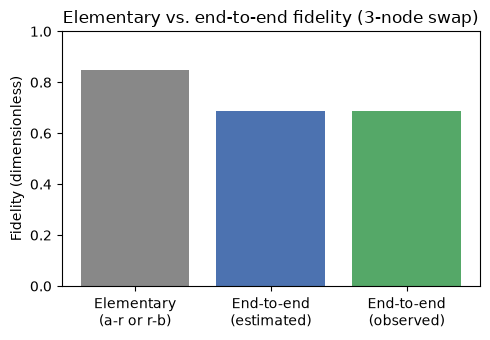

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 3.5))
labels = ["Elementary\n(a-r or r-b)", "End-to-end\n(estimated)", "End-to-end\n(observed)"]
values = [RAW_FIDELITY, plan.estimated_metrics.fidelity, observed_avg_fidelity]
ax.bar(labels, values, color=["#888888", "#4C72B0", "#55A868"])
ax.set_ylabel("Fidelity (dimensionless)")
ax.set_ylim(0, 1)
ax.set_title("Elementary vs. end-to-end fidelity (3-node swap)")
fig.tight_layout()
plt.show()


In [6]:
assert abs(observed_avg_fidelity - plan.estimated_metrics.fidelity) < 0.01, (
    "observed end-to-end fidelity should match the planner's pre-simulation estimate closely "
    "when no purification is involved"
)
print("Planner estimate matches observed fidelity within tolerance.")


Planner estimate matches observed fidelity within tolerance.


## Interpretação
A fidelidade elementar (0.85, igual à `raw_fidelity` configurada) é maior
que a fidelidade fim a fim: o swap em `r` degrada a fidelidade pelo fator
`swapping_degradation` (0.95), e como o entrelaçamento fim a fim depende de
dois enlaces elementares independentes, a fórmula é
`fidelidade_a-r x fidelidade_r-b x degradação = 0.85 x 0.85 x 0.95`. A
estimativa do planner (calculada *antes* de qualquer simulação, em
`planning/feasibility.py`) usa exatamente essa fórmula - por isso bate com
o valor observado dentro de uma tolerância pequena.

## Limitações
- A ordem do swap é decidida internamente pelo SeQUeNCe
  (`ResourceManager.generate_load_rules`, bisseção binária do caminho) -
  não é parametrizável nesta versão (`docs/sequence_code_analysis.md`,
  seção 4.7), mas isso não afeta a fórmula de fidelidade acima
  (multiplicação é associativa).
- Esta demonstração usa `min_fidelity` abaixo do teto de um único swap, de
  propósito, para isolar a física do swapping da purificação (ver o
  próximo notebook).

## Conclusão
Entrelaçamento fim a fim demonstrado numa cadeia de 3 nós, com a
estimativa do planner e o valor realmente observado na simulação
concordando dentro de tolerância pequena.
